# <center>Organizaci&oacute;n de Datos</center>
#### <center>C&aacute;tedra Ing. Rodriguez, Juan Manuel </center>

## <center>Métodos de Regresión</center>
### <center> Práctica Regresión Logística </center>

#### Links interesantes
 * scikit-learn.org
 * pandas.pydata.org
 * scikit-yb.org
 * matplotlib.org
 * seaborn.pydata.org


Importamos las librerías generales que vamos a necesitar

In [ ]:
#Librerías para manejos de datos
import pandas as pd
import numpy as np

#Librerías para gráficos
import matplotlib.pyplot as plt
import seaborn as sns

#Otras librerías
import os
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

Importamos librerías de modelos

In [ ]:
from sklearn.linear_model import LinearRegression   #Regresión Lineal
from sklearn.linear_model import LogisticRegression #Regresión Logística

from sklearn.model_selection import train_test_split, cross_val_score

#### Introducción

### Clasificación Binaria

#### Problema 1: Clasificación simple en 1 dimensión

In [ ]:
#Generamos un dataset sintético

ds=pd.DataFrame()
ds['x']=[1,1.5,1.25,2.1,1.75,-0.5,-0.78,-1.25,-1.5,-1.75] #Valores de X
ds['y']=[1,1,1,1,1,0,0,0,0,0] #Target

ds.head()

,x,y
0,1.00,1
1,1.50,1
2,1.25,1
3,2.10,1
4,1.75,1


Veamos gráficamente el dataset

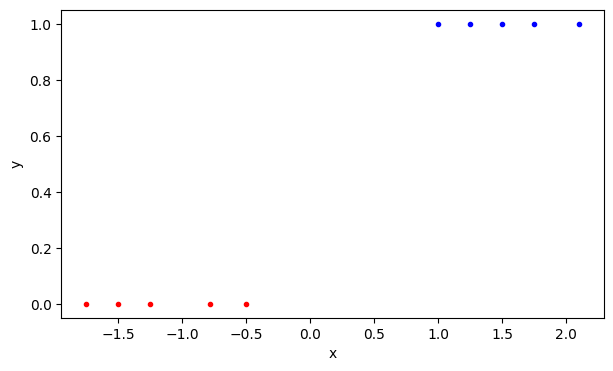

In [ ]:
#Ploteamos
x = ds.x
y = ds.y

plt.figure(figsize=(7, 4))

plt.plot(x[y==0],y[y==0],'r.')  #Los puntos de clase 0 rojos
plt.plot(x[y==1],y[y==1],'b.')  #Los puntos de clase 1 azules

plt.xlabel("x")
plt.ylabel("y")

plt.show()

¿Qué pasa si utilizamos una regresión lineal, para luego separar las clases en función de su resultado?

In [ ]:
#Creo un regresor lineal
modelo_lineal_simple = LinearRegression()

#Doy el formato adecuado a las variables dependiente e independiente
x_=ds.x.values.reshape(-1, 1)
y_=ds.y.values.reshape(-1, 1)

#Ajusto el modelo
modelo_lineal_simple.fit(x_,y_)

#Parámetros estimados
B1_e=round(modelo_lineal_simple.coef_[0][0],2)
B0_e=round(modelo_lineal_simple.intercept_[0],2)

#Muestro el modelo
print(f" El modelo lineal simple ajustado es : y = {B1_e} * X  + {B0_e}")

 El modelo lineal simple ajustado es : y = 0.34 * X  + 0.44


Veamos en un gráfico el modelo ajustado

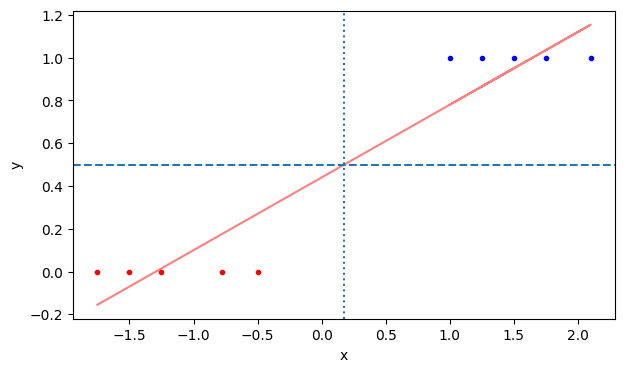

In [ ]:
#Calculo los valores que estima mi modelo lineal simple
corte=0.5

y_e=B1_e *x_ + B0_e
x_limite=(corte-B0_e)/B1_e

#Grafico las observaciones reales + las estimadas
plt.figure(figsize=(7, 4))
plt.xlabel("x")
plt.ylabel("y")

plt.plot(x[y==0],y[y==0],'r.')
plt.plot(x[y==1],y[y==1],'b.')

plt.plot(x_,y_e,label='data', color='red',alpha=0.5)
plt.axvline(x=x_limite,linestyle="dotted")
plt.axhline(y=corte,linestyle="dashed")
plt.show()

Para poder clasificar las observciones necesitamos adoptar un criterio que me permita dividir en 2 clases. <br>

Proponemos el siguiente criterio: si el valor de y estimado por el modelo es mayor a 0,5 entonces la observación pertenecerá a la clase 0 si no a la clase 1.

Parece funcionar bien? Veamos un caso mas complejo

#### Problema 2: Clasificación compleja en 1 dimensión

In [ ]:
ds2=pd.DataFrame()
ds2['x']=[1,0.5,3.15,7.1,3.75,0.1,-0.78,-1.25,-1.5,-1.75,0.1] #Valores de X
ds2['y']=[1,1,1,1,1,0,0,0,0,0,1] #Target

ds2.head()

,x,y
0,1.00,1
1,0.50,1
2,3.15,1
3,7.10,1
4,3.75,1


Veamos gráficamente el dataset

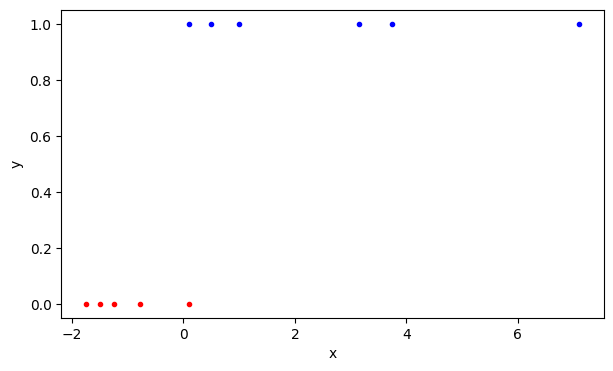

In [ ]:
corte=0.5
x_limite=(corte-B0_e)/B1_e

x2 = ds2.x.values.reshape(11,1)
y2 = ds2.y.values.reshape(11,1)

plt.figure(figsize=(7, 4))
plt.xlabel("x")
plt.ylabel("y")
plt.plot(x2[y2==0],y2[y2==0],'r.')
plt.plot(x2[y2==1],y2[y2==1],'b.')
plt.show()

Ajustemos un modelo y veamos la recta ajustada en un gráfico

In [ ]:
#Creo un regresor lineal
modelo_lineal_simple = LinearRegression()

#Doy el formato adecuado a las variables dependiente e independiente
x2_=x2.reshape(-1, 1)
y2_=y2.reshape(-1, 1)

#Ajusto el modelo
modelo_lineal_simple.fit(x2_,y2_)

#Parámetros estimados
B1_e=round(modelo_lineal_simple.coef_[0][0],2)
B0_e=round(modelo_lineal_simple.intercept_[0],2)

#Muestro el modelo
print(f" El modelo lineal simple ajustado es : y = {B1_e} * X  + {B0_e}")

 El modelo lineal simple ajustado es : y = 0.14 * X  + 0.42


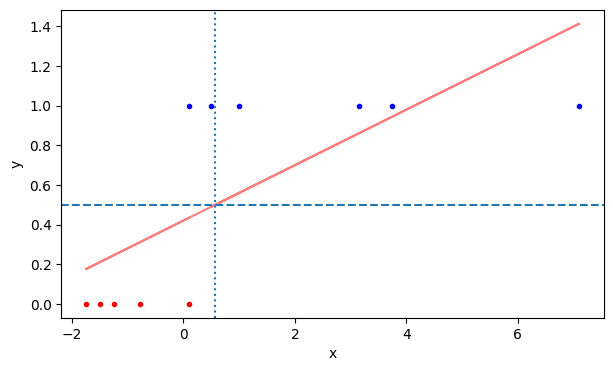

In [ ]:
#Calculo los valores que estima mi modelo lineal simple
corte=0.5

y2_e=B1_e *x2_ + B0_e
x2_limite=(corte-B0_e)/B1_e

#Grafico las observaciones reales + las estimadas
plt.figure(figsize=(7, 4))
plt.xlabel("x")
plt.ylabel("y")

plt.plot(x2[y2==0],y2[y2==0],'r.')
plt.plot(x2[y2==1],y2[y2==1],'b.')
plt.plot(x2_,y2_e,label='data', color='red',alpha=0.5)
plt.axvline(x=x2_limite,linestyle="dotted")
plt.axhline(y=corte,linestyle="dashed")

plt.show()

¿Qué criterio elegirían para separar las clases?


El modelo de regresión lineal puede funcionar bien para la regresión, pero falla para la clasificación. En el caso de dos clases, puede etiquetar una de las clases con 0 y la otra con 1 y usar la regresión lineal. Técnicamente funciona pero hay algunos problemas con este enfoque.<br>

Un modelo lineal no genera probabilidades, pero trata las clases como números (0 y 1) y ajusta el mejor hiperplano (para una sola variables, es una recta) que minimiza las distancias entre los puntos y el hiperplano. Entonces simplemente interpola entre los puntos y no podemos interpretarlo como probabilidades.<br>

Un modelo lineal también extrapola y le da valores por debajo de cero y por encima de uno. Esta es una buena señal de que podría haber un enfoque más inteligente para la clasificación.<br>

Dado que el resultado predicho no es una probabilidad, sino una interpolación lineal entre puntos, no existe un umbral significativo en el que pueda distinguir una clase de otra.<br>

Para resolver este problema resulta más adecuado utilizar la regresión logística.

Recomendamos leer el capítulo de regresión logística de Interpretable Machine Learning: A Guide for Making Black Box Models Explainable de Molnar Cristoph https://christophm.github.io/interpretable-ml-book/logistic.html para mayor detalle

### Regresión Logística

Función Sigmoidea

\begin{equation}
s(z) = \frac{1}{1 + e^{-z}}
\end{equation}

¿Qué forma tiene?

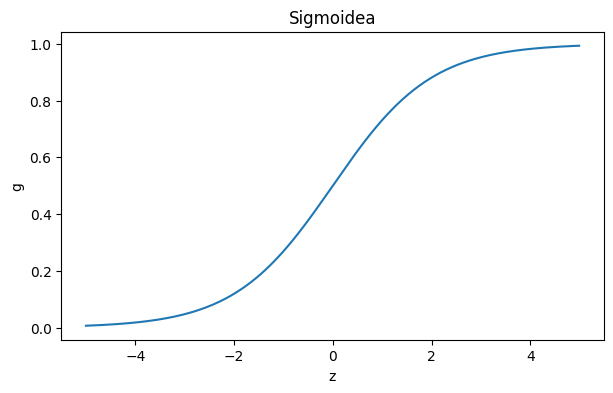

In [ ]:
s = np.arange( -5, 5, 0.01)
g = 1/(1 + np.exp(-s))
plt.figure(figsize=(7, 4))
plt.plot(s,g)
plt.xlabel("z")
plt.ylabel("g")
plt.title("Sigmoidea")
plt.show()

In [40]:
s.shape

(1000,)

In [41]:
g.shape

(1000,)

¿Cuáles son los parámetros del modelo?

$$s_\theta(x) = g(\beta^T x) =  \frac{1}{1+ e^{(-\beta^T x)}}$$

La salida de la función sigmoidea es continua entre 0 y 1, pudiéndose interpretar como probabilidad de pertenencia a la clase 1

Seguimos necesitando definir un umbral, continuemos considerando 0,5
  * Si $s_\beta(x) < 0.5$  entonces $x$ pertencerá a la clase 0
  * Si $s_\beta(x) \ge 0.5$  entonces $x$ pertencerá a la clase 1

Elegir como umbral 0.5 nos da una imterpretación simple de  $\beta^Tx$:
$$ s_\theta(x) = 0.5 \\ \Rightarrow \beta^Tx = 0$$
Es la ecuación de un hiperplano!


Por ejemplo:

$\beta_0 +\beta_1 x_1 + \beta_2 x_2 =0 $

Se puede transformar en:

$- \beta_2 x_2 = \beta_0 +\beta_1 x_1 $

$ x_2 =   - \frac{\beta_1}{\beta_2} x_1 - \frac{\beta_0}{\beta_2}$

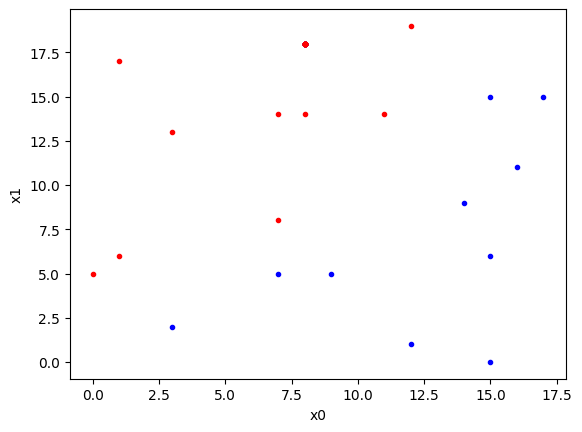

In [ ]:
#Genero un dataset sintético
X = np.random.randint(20,size=(20,2))
beta = np.array([[-0.1],[0.1]])
Y = np.round( 1/(1+np.exp(np.dot(-X, beta))))

ind0 = np.where(Y==0)
ind1 = np.where(Y==1)
plt.plot(X[ind0,0],X[ind0,1],'b.')
plt.plot(X[ind1,0],X[ind1,1],'r.')
plt.xlabel("x0")
plt.ylabel("x1")
plt.show()

Generemos un clasificador de tipo regresión logística

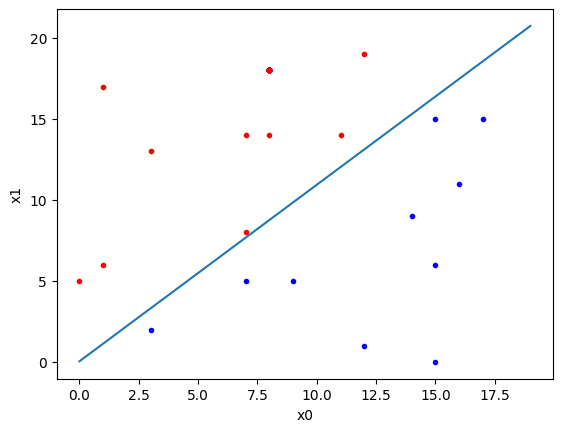

In [ ]:
#Creo el clasificador
clf = LogisticRegression()
clf.fit(X, Y)

#Obtengo coeficientes para el modelo b0 + b1X + b2Y=0
beta_0 = clf.intercept_
beta_1 = clf.coef_[0,0]
beta_2 = clf.coef_[0,1]

#Graficamos
x1 = np.arange(0,20,1)
x2 = - beta_1/beta_2*x1 - beta_0/beta_2
plt.plot(x1,x2)

ind0 = np.where(Y==0)
ind1 = np.where(Y==1)
plt.plot(X[ind0,0],X[ind0,1],'b.')
plt.plot(X[ind1,0],X[ind1,1],'r.')
plt.xlabel("x0")
plt.ylabel("x1")
plt.show()

Volviendo a nuestro ejemplo complejo de 1 dimensión

In [ ]:
x2 = ds2.x.values.reshape(11,1)
y2 = ds2.y.values.reshape(11,1)

modelo_rl = LogisticRegression()
modelo_rl.fit(x2, y2)

y_pred_modelo_rl = modelo_rl.predict(x2)

# ordeno el input a predecir unicamente con fines graficos posteriores
sorted_x2 = np.sort(x2.ravel()).reshape(x2.shape)
y_pred_proba_modelo_rl = modelo_rl.predict_proba(sorted_x2)[:, 1]

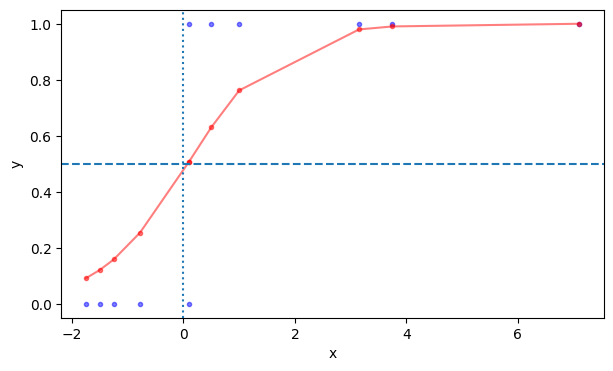

In [ ]:
#Calculo los valores que estima mi modelo lineal simple
corte=0.5

y2_e=B1_e *x2_ + B0_e
x2_limite=0

#Grafico las observaciones reales + las estimadas
plt.figure(figsize=(7, 4))
plt.xlabel("x")
plt.ylabel("y")
plt.scatter(x2,y2,label='data', color='blue',alpha=0.5,marker='.')
plt.plot(sorted_x2,y_pred_proba_modelo_rl,label='data', color='red',alpha=0.5,marker='.')
plt.axvline(x=x2_limite,linestyle="dotted")
plt.axhline(y=corte,linestyle="dashed")
plt.show()